В данном ноутбуке строятся модели коллаборативной фильтрации для построения рекомендаций для пользователей.

В качестве бейзлайна берется рандомный рекоммендер.

**ItemBased Collaborative filtering**
- Строим матрицу похожести фильмов. На основании понравившихся пользователю ранее фильмах, выбираем похожие, рекомендуем пользователю.

**UserBased Collaborative filtering**
- Строим матрицу похожести пользователей. На основании похожих пользователей и понравившихся им фильмах, выдаем рекомендации.

**Оценка**
- Модели оцениваются на оффлайн метриках (ndcg@k, recall@k, precision@k) и для оценки ошибки MAE, RMSE 

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
import pickle

DATA_PATH = '../src/data/preprocessed_data/full_data.parquet'

ARTIFACTS_DIR = '../artifacts'
FIGURES_DIR = Path(ARTIFACTS_DIR) / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', None)
np.random.seed(42)


In [3]:
df = pd.read_parquet(path=DATA_PATH, columns=['userId', 'title', 'movieId', 'rating', 'timestamp'])
df.head()

,userId,title,movieId,rating,timestamp
0,1,Toy Story (1995),1,4.0,2000-07-30 18:45:03
1,5,Toy Story (1995),1,4.0,2000-07-30 18:20:47
2,7,Toy Story (1995),1,4.5,2000-07-30 18:37:04
3,15,Toy Story (1995),1,2.5,2000-07-30 19:03:35
4,17,Toy Story (1995),1,4.5,2000-07-30 18:48:51


In [4]:
def precision_at_k(relevant, recommended, k=10):
    recommended_k = recommended[:k]
    hits = len(set(relevant) & set(recommended_k))
    return hits / k if k > 0 else 0

def recall_at_k(relevant, recommended, k=10):
    recommended_k = set(recommended[:k])
    hits = len(set(relevant) & recommended_k)
    return hits / len(relevant) if relevant else 0

def ndcg_at_k(relevant_with_ratings, recommended, k=10):
    recommended_k = recommended[:k]

    dcg = 0
    for i, item in enumerate(recommended_k):
        if item in relevant_with_ratings:
            gain = 2 ** relevant_with_ratings[item] - 1
            dcg += gain / np.log2(i + 2)
    
    sorted_ratings = sorted(relevant_with_ratings.values(), reverse=True)[:k]
    idcg = 0
    for i, rating in enumerate(sorted_ratings):
        gain = 2 ** rating - 1
        idcg += gain / np.log2(i + 2)
    
    return dcg / idcg if idcg > 0 else 0

def evaluate_model(recommend_func, data_df, all_items, k=10, verbose=False):
    precisions = []
    recalls = []
    ndcgs = []
    users_processed = 0
    
    for user_id in data_df['userId'].unique():
        user_data = data_df[data_df['userId'] == user_id]
        relevant = user_data[user_data['rating'] >= 3.5]
        
        if len(relevant) == 0:
            continue
        
        relevant_ids = relevant['movieId'].tolist()
        relevant_dict = dict(zip(relevant['movieId'], relevant['rating']))
        
        recommendations = recommend_func(user_id, all_items, k)
        
        precisions.append(precision_at_k(relevant_ids, recommendations, k))
        recalls.append(recall_at_k(relevant_ids, recommendations, k))
        ndcgs.append(ndcg_at_k(relevant_dict, recommendations, k))
        
        users_processed += 1
        if verbose and users_processed % 100 == 0:
            print(f"  Обработано {users_processed} пользователей...")
    
    return {
        'precision@10': np.mean(precisions),
        'recall@10': np.mean(recalls),
        'ndcg@10': np.mean(ndcgs),
    }



In [5]:
df_sorted = df.sort_values('timestamp').reset_index(drop=True)
n = len(df_sorted)
end_train = int(n * 0.7)
end_val = int(n * 0.85)

train_val, test_df = train_test_split(df, test_size=0.15, random_state=42)

train_df, val_df = train_test_split(train_val, test_size=0.176, random_state=42)

print(f'Размер train: {train_df.shape}')
print(f'Размер validation: {val_df.shape}')
print(f'Размер test: {test_df.shape}')

Размер train: (70625, 5)
Размер validation: (15085, 5)
Размер test: (15126, 5)


In [6]:
import random

class RandomRecommender:
    def recommend(self, user_id, all_items, k=10):
        return random.sample(all_items, min(k, len(all_items)))
    
    def predict(self, user_id, movie_id):
        return random.uniform(1.0, 5.0)

random_model = RandomRecommender()
metrics = evaluate_model(lambda u, a, k: random_model.recommend(u, a, k), 
                        val_df, 
                        df_sorted['movieId'].unique().tolist(), 
                        k=10)

def evaluate_loss_rating_predictions(model, test_df):
    predictions = []
    actuals = []
    
    for _, row in test_df.iterrows():
        pred = model.predict(row['userId'], row['movieId'])
        predictions.append(pred)
        actuals.append(row['rating'])
    
    mae = np.mean(np.abs(np.array(actuals) - np.array(predictions)))
    rmse = np.sqrt(np.mean((np.array(actuals) - np.array(predictions))**2))
    
    return {
        'MAE': mae, 
        'RMSE': rmse
            }

metrics.update(evaluate_loss_rating_predictions(random_model, val_df))

print(f"Random model NDCG@10: {metrics['ndcg@10']:.4f}")
print(f'Random model Recall@10: {metrics['recall@10']:.4f}')
print(f'Random model Precision@10: {metrics['precision@10']:.4f}')
print(f'Random model MAE: {metrics['MAE']:.4f}')
print(f'Random model RMSE: {metrics['RMSE']:.4f}')

Random model NDCG@10: 0.0014
Random model Recall@10: 0.0012
Random model Precision@10: 0.0017
Random model MAE: 1.3378
Random model RMSE: 1.6374


In [7]:
user_item_df = df.pivot_table(index=["userId"], columns=["movieId"], values="rating").fillna(0)
user_item_df.head()

movieId  1       2       3       4       5       6       7       8       \
userId                                                                    
1           4.0     0.0     4.0     0.0     0.0     4.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  9       10      11      12      13      14      15      16      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  17      18      19      20      21      22      23      24      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     3.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     4.0     0.0     0.0     0.0   

movieId  25      26      27      28      29      30      31      32      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.5     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     2.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   

movieId  34      36      38      39      40      41      42      43      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
5           4.0     4.0     0.0     3.0     0.0     0.0     0.0     0.0   

movieId  44      45      46      47      48      49      50      52      \
userId                                                                    
1           0.0     0.0     0.0     5.0     0.0     0.0     5.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     3.0     0.0     2.0     0.0     0.0     0.0     3.0   
5           0.0     0.0     0.0     0.0     0.0     0.0     4.0     0.0   

movieId  53      54      55      57      58      60      61      62      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
4           0.0     0.0     0.0     0.0     3.0     0.0     0.0     0.0   
5           0.0     0.0     0.0     0.0     5.0     0.0     0.0     0.0   

movieId  63      64      65      66      68      69      70      71      \
userId                                                                    
1           0.0     0.0     0.0     0.0     0.0     0.0     3.0     0.0   
2           0.0     0.0     0.0     0.0     0.0     0.0     0.0     0.0   
3           0.0   

In [8]:
class ItemCFRecommender():
    def fit(self, train_df):
        self.user_item_matrix = train_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)
        item_user_matrix = self.user_item_matrix.T
        self.movie_ids = item_user_matrix.index.tolist()
        self.movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(self.movie_ids)}
        self.cosine_similarity_matrix = cosine_similarity(item_user_matrix)

        return self

    def predict(self, user_id, movie_id):
        if user_id not in self.user_item_matrix.index:
            return 3.0
        
        user_ratings = self.user_item_matrix.loc[user_id]
        liked_films = user_ratings[user_ratings > 0].index.tolist()
        
        if not liked_films or movie_id not in self.movie_to_idx:
            return user_ratings.mean() if user_ratings.mean() > 0 else 3.0
        
        movie_idx = self.movie_to_idx[movie_id]
        similarity_row = self.cosine_similarity_matrix[movie_idx]
        
        similarities = []
        ratings = []
        
        for liked in liked_films:
            liked_idx = self.movie_to_idx[liked]
            sim = similarity_row[liked_idx]
            if sim > 0:
                similarities.append(sim)
                ratings.append(user_ratings[liked])
        
        if not similarities:
            return user_ratings.mean()
        
        pred = np.average(ratings, weights=similarities)
        return np.clip(pred, 0.5, 5.0)

    def recommend(self, user_id, all_items, k=10):
        if user_id not in self.user_item_matrix.index:
            return []
    
        user_ratings = self.user_item_matrix.loc[user_id]
        liked_mask = user_ratings > 3.5
        liked_films = user_ratings[liked_mask].index.tolist()
    
        if not liked_films:
            return []
    

        liked_indices = [self.movie_to_idx[m] for m in liked_films]
        sim_matrix_subset = self.cosine_similarity_matrix[liked_indices]
        total_scores = sim_matrix_subset.sum(axis=0)
        sorted_indices = np.argsort(total_scores)[::-1]
    
        recommendations = []
        for idx in sorted_indices:
            movie = self.movie_ids[idx]
            if movie not in liked_films and len(recommendations) < k:
                recommendations.append(movie)
    
        return recommendations
    


In [9]:
all_items = df['movieId'].unique().tolist()
item_model = ItemCFRecommender()
item_model.fit(train_df)
item_model_metrics = evaluate_model(
    lambda user_id, all_items, k: item_model.recommend(user_id, all_items, k),
    val_df,
    all_items,
    k=10
)
item_model_metrics.update(evaluate_loss_rating_predictions(item_model, val_df))
print(f"Item model NDCG@10: {item_model_metrics['ndcg@10']:.4f}")
print(f'Item model Recall@10: {item_model_metrics['recall@10']:.4f}')
print(f'Item model Precision@10: {item_model_metrics['precision@10']:.4f}')
print(f'Item model MAE: {item_model_metrics['MAE']:.4f}')
print(f'Item model RMSE: {item_model_metrics['RMSE']:.4f}')

Item model NDCG@10: 0.1051
Item model Recall@10: 0.1259
Item model Precision@10: 0.0715
Item model MAE: 0.8046
Item model RMSE: 1.1180


In [10]:
class UserCFRecommender():
    def fit(self, train_df):
        self.user_item_matrix = train_df.pivot(index='userId', columns='movieId', values='rating').fillna(0)
        item_user_matrix = self.user_item_matrix.T
        self.movie_ids = item_user_matrix.index.tolist()
        self.user_ids = self.user_item_matrix.index.tolist()
        self.user_to_idx = {user_id: idx for idx, user_id in enumerate(self.user_ids)}
        self.movie_to_idx = {movie_id: idx for idx, movie_id in enumerate(self.movie_ids)}
        self.user_similarity_matrix = cosine_similarity(self.user_item_matrix)

        return self

    def predict(self, user_id, movie_id):
        if user_id not in self.user_item_matrix.index:
            return 3.0
        user_idx = self.user_to_idx[user_id]
        similarity_row = self.user_similarity_matrix[user_idx]
        if movie_id not in self.user_item_matrix.columns:
            return 3.0
    
        movie_ratings = self.user_item_matrix[movie_id].values
        mask = movie_ratings > 0
        if not mask.any():
            return self.user_item_matrix.loc[user_id].mean()
    
        similarities = similarity_row[mask]
        ratings = movie_ratings[mask]
    
        if similarities.sum() == 0:
            return ratings.mean()
    
        pred = np.average(ratings, weights=similarities)
        return np.clip(pred, 0.5, 5.0)

    def recommend(self, user_id, k=10):
        if not isinstance(self.user_item_matrix.index[0], (int, np.integer)):
            self.user_item_matrix.index = self.user_item_matrix.index.astype(int)
            self.user_to_idx = {int(k): v for k, v in self.user_to_idx.items()}
    
        user_id = int(user_id)
        if user_id not in self.user_item_matrix.index:
            return []

        user_idx = self.user_to_idx[user_id]

        similarity_row = self.user_similarity_matrix[user_idx] 
    
        ratings_matrix = self.user_item_matrix.values  
    
        weighted_ratings = ratings_matrix * similarity_row[:, np.newaxis] 
        total_scores = weighted_ratings.sum(axis=0)
    
        sum_weights = similarity_row.sum()
        if sum_weights > 0:
            total_scores = total_scores / sum_weights

        user_ratings = self.user_item_matrix.loc[user_id].values
        already_rated_mask = user_ratings > 0
        total_scores[already_rated_mask] = -1

        top_indices = np.argsort(total_scores)[::-1][:k]
        return [self.movie_ids[idx] for idx in top_indices if total_scores[idx] > 0]

In [11]:
all_items = df['movieId'].unique().tolist()

user_model = UserCFRecommender()
user_model.fit(train_df)

user_model_metrics = evaluate_model(
    lambda user_id, all_items, k: user_model.recommend(user_id, k),
    val_df,
    all_items,
    k=10
)

rating_metrics = evaluate_loss_rating_predictions(user_model, val_df)
user_model_metrics.update(rating_metrics)

print(f"User model NDCG@10: {user_model_metrics['ndcg@10']:.4f}")
print(f"User model Recall@10: {user_model_metrics['recall@10']:.4f}")
print(f"User model Precision@10: {user_model_metrics['precision@10']:.4f}")
print(f"User model MAE: {user_model_metrics['MAE']:.4f}")
print(f"User model RMSE: {user_model_metrics['RMSE']:.4f}")

User model NDCG@10: 0.1578
User model Recall@10: 0.1408
User model Precision@10: 0.1182
User model MAE: 0.7505
User model RMSE: 0.9736


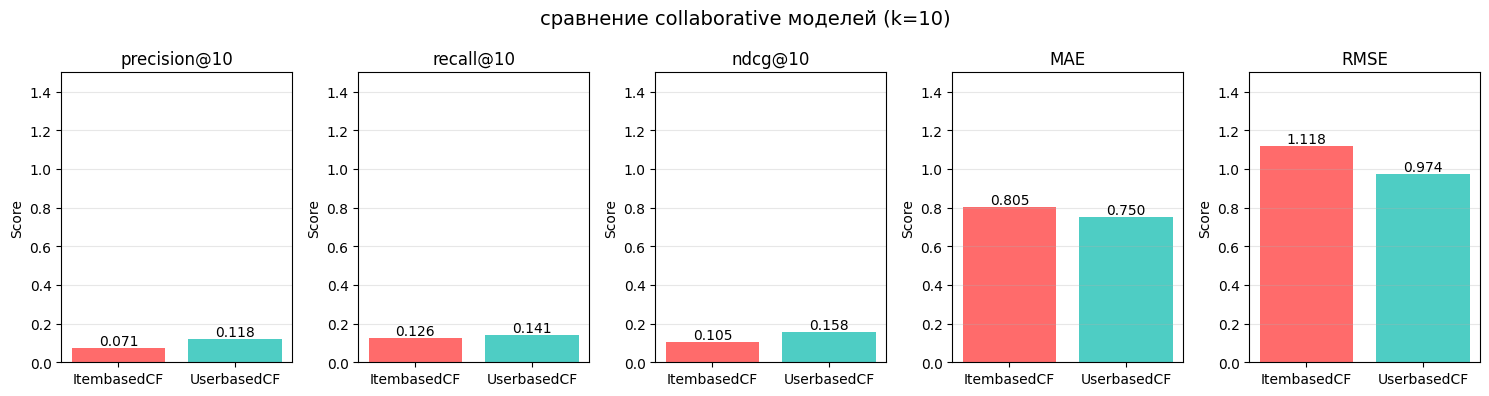

In [12]:
fig, axes = plt.subplots(1, 5, figsize=(15, 4))

metrics = ['precision@10', 'recall@10', 'ndcg@10', 'MAE', 'RMSE']
models = ['ItembasedCF', 'UserbasedCF']
values = [item_model_metrics, user_model_metrics]

for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(models, 
                  [item_model_metrics[metric], user_model_metrics[metric], ],
                  color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    ax.set_title(metric, fontsize=12)
    ax.set_ylim(0, 1.5)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('сравнение collaborative моделей (k=10)', fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR/'cf_metrics_comparasion.png')
plt.show()


Примеры рекомендаций от моделей

In [13]:
user_id = 1
movie_titles = train_df[['movieId', 'title']].drop_duplicates().set_index('movieId')['title'].to_dict()
usercf_rec_ids = user_model.recommend(user_id, k=10)
usercf_rec_titles = [movie_titles.get(mid, f"Film_{mid}") for mid in usercf_rec_ids]

print(f"Рекомендации для пользователя {user_id}:")
for i, title in enumerate(usercf_rec_titles, 1):
    print(f"  {i}. {title}")

Рекомендации для пользователя 1:
  1. Pulp Fiction (1994)
  2. Shawshank Redemption, The (1994)
  3. Star Wars: Episode V - The Empire Strikes Back (1980)
  4. Jurassic Park (1993)
  5. Terminator 2: Judgment Day (1991)
  6. Schindler's List (1993)
  7. Saving Private Ryan (1998)
  8. Sixth Sense, The (1999)
  9. Godfather, The (1972)
  10. Seven (a.k.a. Se7en) (1995)


In [14]:
itemcf_rec_ids = item_model.recommend(user_id, df, k=10)
itemcf_rec_titles =  [movie_titles.get(mid, f"Film_{mid}") for mid in itemcf_rec_ids]
print(f"Рекомендации для пользователя {user_id}:")
for i, title in enumerate(itemcf_rec_titles, 1):
    print(f"  {i}. {title}")

Рекомендации для пользователя 1:
  1. Ghostbusters (a.k.a. Ghost Busters) (1984)
  2. Total Recall (1990)
  3. Big (1988)
  4. Star Wars: Episode V - The Empire Strikes Back (1980)
  5. Men in Black (a.k.a. MIB) (1997)
  6. Spaceballs (1987)
  7. Starship Troopers (1997)
  8. Alien (1979)
  9. Breakfast Club, The (1985)
  10. Wizard of Oz, The (1939)


In [ ]:
MODEL_DIR = Path('../src/models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

user_similarity = cosine_similarity(user_item_df)
user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_item_df.index,
    columns=user_item_df.index
)
model_data = {
    'user_similarity_matrix': user_similarity_df,      
    'user_ratings_matrix': user_item_df,          
    'all_movies': df_sorted['movieId'].unique().tolist()  
}

with open(MODEL_DIR / 'usercf_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print(f"usercf охранена в {MODEL_DIR / 'usercf_model.pkl'}")

usercf охранена в ..\src\models\usercf_model.pkl
